In [60]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [126]:
# =============================================================================
# 1. STAGE 1: CIC FILTER
# =============================================================================
def cic_stage1(R1=16, M=1, N=4, fs_in=12500000.0):
    """
    Computes Stage 1 CIC filter responses.
    Output rate: fs_in / R1 (e.g., 12.5 MHz / 16 = 781.25 kHz)
    """
    fs_out = fs_in / R1
    dc_gain = (R1 * M) ** N
    
    # Pre-Decimation Frequency Evaluation (0 to fs_in / 2)
    f_in = np.linspace(1e-5, fs_in / 2, 200000)
    omega_in = 2 * np.pi * f_in / fs_in
    
    num_in = 1 - np.exp(-1j * omega_in * R1 * M)
    den_in = 1 - np.exp(-1j * omega_in)
    H_cic_in = np.where(np.abs(den_in) < 1e-12, dc_gain, num_in / den_in) ** N
    H_cic_in_norm = H_cic_in / dc_gain  # Normalized to 0 dB DC gain
    
    # Post-Decimation Folded Spectrum (0 to fs_out / 2)
    nyq_out = fs_out / 2.0
    f_out = np.linspace(1e-5, nyq_out, 2000)
    H_folded = np.zeros(len(f_out), dtype=complex)
    
    for k in range(R1):
        f_shifted = f_out + (k * fs_out)
        omega_k = 2 * np.pi * f_shifted / fs_in
        num_k = 1 - np.exp(-1j * omega_k * R1 * M)
        den_k = 1 - np.exp(-1j * omega_k)
        H_k = np.where(np.abs(den_k) < 1e-12, dc_gain, num_k / den_k) ** N
        H_folded += (H_k / dc_gain)
        
    H_folded = H_folded / R1
    
    outputs = {
        'stage_name': 'Stage 1: CIC Filter',
        'fs_in': fs_in,
        'fs_out': fs_out,
        'R_stage': R1,
        'R_cumulative': R1,
        'f_in_grid': f_in,
        'H_standalone_in': H_cic_in_norm,
        'H_cascade_in': H_cic_in_norm,      # At stage 1, cascade = standalone
        'f_out_grid': f_out,
        'H_folded_cascade': H_folded
    }
    return outputs

In [62]:
# =============================================================================
# 2. STAGE 2: CASCADED HALF-BAND FIR FILTERS
# =============================================================================
def design_halfband_fir(num_taps=31):
    """Designs a Type-1 Linear Phase Half-Band FIR filter."""
    if num_taps % 2 == 0:
        num_taps += 1
    taps = signal.firwin(num_taps, 0.25, window=('kaiser', 5.0), fs=1.0)
    center = num_taps // 2
    for i in range(num_taps):
        if (i - center) % 2 == 0 and i != center:
            taps[i] = 0.0
    taps[center] = 0.5
    return taps

In [63]:
def half_band_fir_stage2(stage1_outputs, hb_taps_count=31, num_hb_stages=4):
    """
    Computes Stage 2 (4x Half-Band FIR) responses using Stage 1 output settings.
    Output rate: fs_stage1_out / (2^num_hb_stages) = 781.25 kHz / 16 = 48.83 kHz
    """
    fs_in_system = stage1_outputs['fs_in']
    fs_stage2_in = stage1_outputs['fs_out']
    R2 = 2 ** num_hb_stages
    fs_out = fs_stage2_in / R2
    R_cum = stage1_outputs['R_cumulative'] * R2
    
    hb_taps = design_halfband_fir(hb_taps_count)
    n_hb = np.arange(len(hb_taps))
    
    # 1. Compute Standalone Stage 2 Response across full system input grid
    f_in = stage1_outputs['f_in_grid']
    H_hb_cascade_in = np.ones(len(f_in), dtype=complex)
    
    # Multiply all 4 half-band stages operating at decreasing rates
    for i in range(num_hb_stages):
        fs_current = fs_stage2_in / (2 ** i)
        omega_stage = 2 * np.pi * f_in / fs_current
        H_stage = np.dot(np.exp(-1j * np.outer(omega_stage, n_hb)), hb_taps)
        H_hb_cascade_in *= H_stage
        
    # Combine with Stage 1 for total cumulative response
    H_cascade_cum_in = stage1_outputs['H_cascade_in'] * H_hb_cascade_in
    
    # 2. Compute Folded Post-Decimation Response (0 to fs_out / 2)
    nyq_out = fs_out / 2.0
    f_out = np.linspace(1e-5, nyq_out, 2000)
    H_folded = np.zeros(len(f_out), dtype=complex)
    
    for k in range(R_cum):
        f_shifted = f_out + (k * fs_out)
        
        # Stage 1 CIC component
        omega_k_cic = 2 * np.pi * f_shifted / fs_in_system
        num_k = 1 - np.exp(-1j * omega_k_cic * 16 * 1)
        den_k = 1 - np.exp(-1j * omega_k_cic)
        H_cic_k = np.where(np.abs(den_k) < 1e-12, 16**4, num_k / den_k) ** 4 / (16**4)
        
        # Stage 2 HB components
        H_hb_k = 1.0 + 0j
        for i in range(num_hb_stages):
            fs_curr = fs_stage2_in / (2 ** i)
            omega_k_hb = 2 * np.pi * f_shifted / fs_curr
            H_hb_k *= np.dot(np.exp(-1j * np.outer(omega_k_hb, n_hb)), hb_taps)
            
        H_folded += (H_cic_k * H_hb_k)
        
    H_folded = H_folded / R_cum
    
    outputs = {
        'stage_name': 'Stage 2: Half-Band FIR Cascade (4x HB)',
        'fs_in': fs_in_system,
        'fs_out': fs_out,
        'R_stage': R2,
        'R_cumulative': R_cum,
        'f_in_grid': f_in,
        'H_standalone_in': H_hb_cascade_in,
        'H_cascade_in': H_cascade_cum_in,
        'f_out_grid': f_out,
        'H_folded_cascade': H_folded
    }
    return outputs

In [106]:
# =============================================================================
# 3. STAGE 3: CIC COMPENSATION FIR FILTER
# =============================================================================
def fir_stage3(stage2_outputs, num_taps=32, R3=2, f_passband=10000.0):
    """
    Computes Stage 3 Inverse-Sinc Compensation FIR filter responses.
    Output rate: fs_stage2_out / 2 = 48.83 kHz / 2 = 24.41 kHz
    """
    fs_in_system = stage2_outputs['fs_in']
    fs_stage3_in = stage2_outputs['fs_out']
    fs_out = fs_stage3_in / R3
    R_cum = stage2_outputs['R_cumulative'] * R3
    
    # Design Inverse-Sinc Taps via Least Squares
    nyq_in3 = fs_stage3_in / 2.0
    f_stop = fs_stage3_in / 4.0
    bands = [0, f_passband, f_stop, nyq_in3]
    
    f_fit = np.linspace(0, f_passband, 20)
    omega_fit = 2 * np.pi * f_fit / fs_in_system
    num_fit = np.sin(omega_fit * 16 * 1 / 2.0)
    den_fit = np.sin(omega_fit / 2.0)
    H_fit = np.ones_like(f_fit)
    mask = omega_fit > 0
    H_fit[mask] = np.abs(num_fit[mask] / den_fit[mask]) ** 4 / (16**4)
    desired_pass = 1.0 / H_fit
    desired = [desired_pass[0], desired_pass[-1], 0.0, 0.0]
    
    taps = signal.firls(num_taps, bands, desired, fs=fs_stage3_in)
    taps = taps / np.sum(taps)  # Normalize DC gain
    n_taps = np.arange(len(taps))
    
    # 1. Compute Standalone Stage 3 Response across full system input grid
    f_in = stage2_outputs['f_in_grid']
    omega_stage3_grid = 2 * np.pi * f_in / fs_stage3_in
    H_stage3_in = np.dot(np.exp(-1j * np.outer(omega_stage3_grid, n_taps)), taps)
    
    # Combine with Stage 1+2 for final system cumulative response
    H_cascade_cum_in = stage2_outputs['H_cascade_in'] * H_stage3_in
    
    # 2. Compute Folded Post-Decimation Response (0 to fs_out / 2)
    nyq_out = fs_out / 2.0
    f_out = np.linspace(1e-5, nyq_out, 2000)
    H_folded = np.zeros(len(f_out), dtype=complex)
    
    # Stage 2 taps needed for fold summation
    hb_taps = design_halfband_fir(31)
    n_hb = np.arange(len(hb_taps))
    fs_stage1_out = fs_in_system / 16
    
    for k in range(R_cum):
        f_shifted = f_out + (k * fs_out)
        
        # Stage 1 CIC
        omega_k_cic = 2 * np.pi * f_shifted / fs_in_system
        num_k = 1 - np.exp(-1j * omega_k_cic * 16 * 1)
        den_k = 1 - np.exp(-1j * omega_k_cic)
        H_cic_k = np.where(np.abs(den_k) < 1e-12, 16**4, num_k / den_k) ** 4 / (16**4)
        
        # Stage 2 HB
        H_hb_k = 1.0 + 0j
        for i in range(4):
            fs_curr = fs_stage1_out / (2 ** i)
            omega_k_hb = 2 * np.pi * f_shifted / fs_curr
            H_hb_k *= np.dot(np.exp(-1j * np.outer(omega_k_hb, n_hb)), hb_taps)
            
        # Stage 3 FIR
        omega_k_st3 = 2 * np.pi * f_shifted / fs_stage3_in
        H_st3_k = np.dot(np.exp(-1j * np.outer(omega_k_st3, n_taps)), taps)
        
        H_folded += (H_cic_k * H_hb_k * H_st3_k)
        
    H_folded = H_folded / R_cum
    
    outputs = {
        'stage_name': 'Stage 3: CIC Compensation FIR',
        'fs_in': fs_in_system,
        'fs_out': fs_out,
        'R_stage': R3,
        'R_cumulative': R_cum,
        'f_in_grid': f_in,
        'H_standalone_in': H_stage3_in,
        'H_cascade_in': H_cascade_cum_in,
        'f_out_grid': f_out,
        'H_folded_cascade': H_folded
    }
    return outputs

In [122]:
# =============================================================================
# 4. UNIVERSAL GRAPH PLOTTER
# =============================================================================
def graph_plotter(stage_data, x_lim=8e3, x_lim_2=10e3):
    """
    Plots two-panel spectral visualizations for any given stage data dictionary.
    """
    f_in = stage_data['f_in_grid']
    mag_standalone_db = 20 * np.log10(np.abs(stage_data['H_standalone_in']) + 1e-12)
    mag_cascade_db = 20 * np.log10(np.abs(stage_data['H_cascade_in']) + 1e-12)
    
    f_out = stage_data['f_out_grid']
    mag_folded_db = 20 * np.log10(np.abs(stage_data['H_folded_cascade']) + 1e-12)
    
    fs_in = stage_data['fs_in']
    fs_out = stage_data['fs_out']
    nyq_out = fs_out / 2.0
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))
    
    # Subplot 1: Frequency Domain Response on Input Grid
    ax1.plot(f_in / 1e3, mag_standalone_db, '--', color='gray', alpha=0.7, label='Standalone Stage Response')
    ax1.plot(f_in / 1e3, mag_cascade_db, color='blue', linewidth=2, label='Cumulative Cascaded Response')
    ax1.axvline(nyq_out / 1e3, color='red', linestyle='--', label=f'Output Nyquist ({nyq_out/1e3:.2f} kHz)')
    
    ax1.set_title(f"{stage_data['stage_name']} - Pre-Decimation Response\n(Input Clock: {fs_in/1e6:.2f} MHz | Output Clock: {fs_out/1e3:.2f} kHz)")
    ax1.set_xlabel('Frequency (kHz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_ylim([-120, 15])
    ax1.set_xlim([0, x_lim])
    ax1.grid(True, linestyle='-', alpha=0.4)
    ax1.legend(loc='upper right')

    # Subplot 2: Post-Decimation Baseband Spectrum
    ax2.plot(f_out / 1e3, mag_folded_db, color='purple', linewidth=2, label='Decimated Composite Baseband')
    ax2.set_title(f"{stage_data['stage_name']} - Post-Decimation Folded Spectrum (R_total = {stage_data['R_cumulative']})")
    ax2.set_xlabel('Baseband Frequency (kHz)')
    ax2.set_ylabel('Magnitude (dB)')
    ax2.set_ylim([-120, 15])
    ax2.set_xlim([0, x_lim_2])
    ax2.grid(True, linestyle='-', alpha=0.4)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
    print(mag_standalone_db)

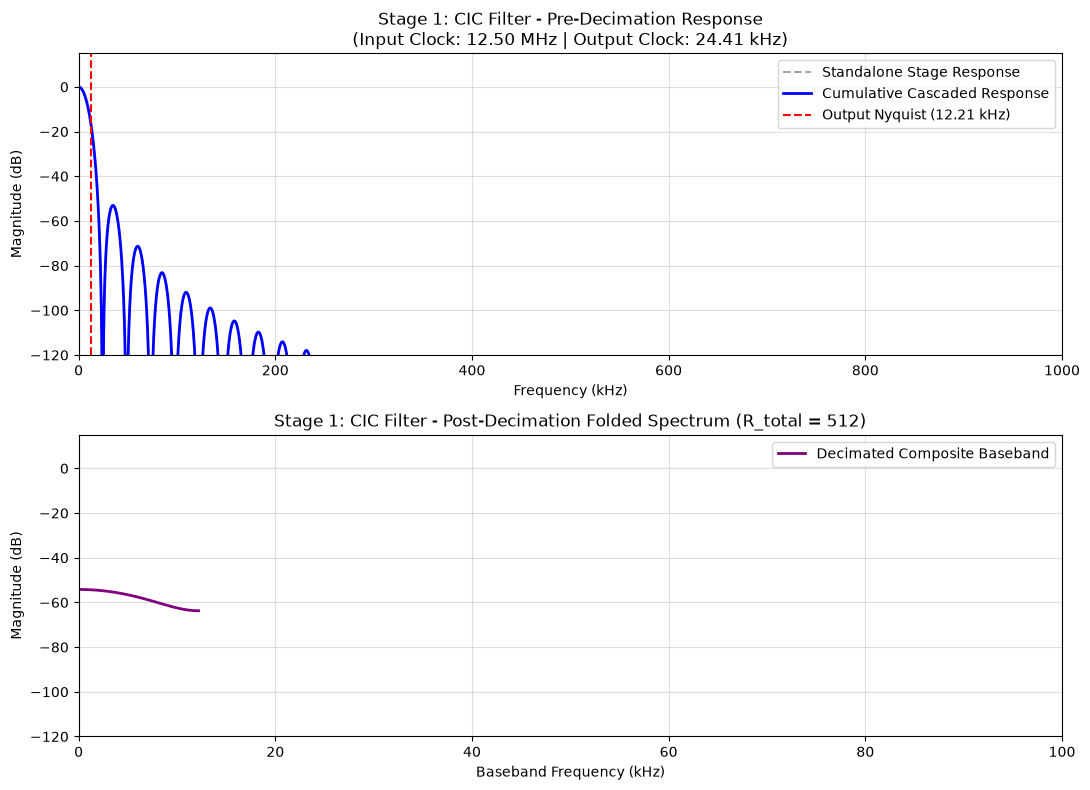

[ 8.68666182e-12 -9.36366549e-05 -3.74547132e-04 ... -2.39999999e+02
 -2.40000000e+02 -2.40000000e+02]


In [128]:
FS_SYSTEM = 12500000.0
    
# -------------------------------------------------------------------------
# STAGE 1: CIC Filter
# -------------------------------------------------------------------------
out_stage1 = cic_stage1(R1=512, M=1, N=4, fs_in=FS_SYSTEM)
graph_plotter(out_stage1,1e3, 0.1e3)

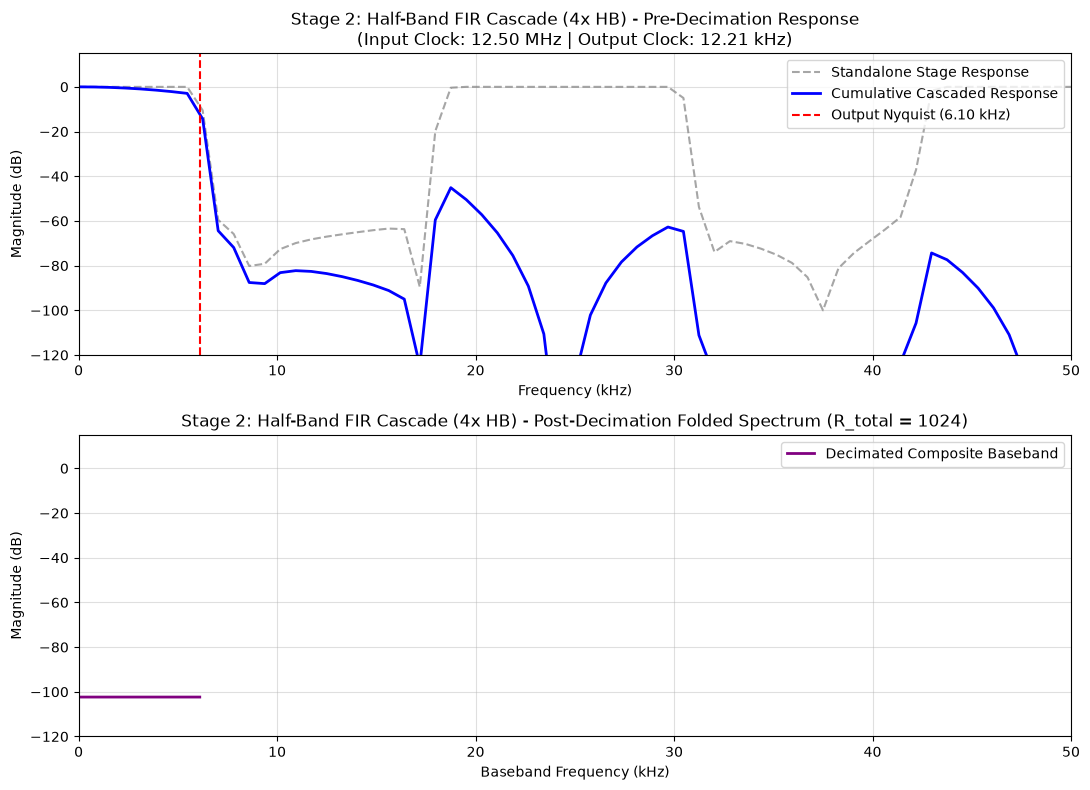

In [120]:
# -------------------------------------------------------------------------
# STAGE 2: 4x Half-Band FIR Cascade
# -------------------------------------------------------------------------
out_stage2 = half_band_fir_stage2(out_stage1, hb_taps_count=65, num_hb_stages=1)
graph_plotter(out_stage2,0.05e3, 0.05e3)

In [1]:
# -------------------------------------------------------------------------
# STAGE 3: CIC Compensation FIR
# -------------------------------------------------------------------------
out_stage3 = fir_stage3(out_stage2, num_taps=127, R3=2, f_passband=12000.0)
graph_plotter(out_stage3,0.1e3, 0.025e3)

NameError: name 'fir_stage3' is not defined